# Creación de Segmentador Supervisado

In [ ]:
"""
Clasificador restringido — predice nivel_cluster usando SOLO variables auto-medibles
----------------------------------------------------------------------------------------
Contexto: el GMM (notebook anterior) usó variables de laboratorio (fuerza de agarre,
VO2max, % grasa corporal) que la app NUNCA puede pedirle al usuario. Este notebook
entrena el modelo que SÍ corre en producción: predice nivel_cluster usando solo lo
que el usuario puede reportar/medir en casa, e intenta reconstruir la información de
laboratorio perdida mediante feature engineering, para acercarse lo más posible al
desempeño del modelo no supervisado original.

Estructura (igual que el notebook de clustering):
1. Carga del dataset ya etiquetado (nivel_cluster)
2. Definición de variables restringidas (auto-medibles)
3. Feature engineering básico (derivadas simples, sin necesidad de modelos)
4. Reconstrucción de % grasa corporal (fórmula de Deurenberg — real, publicada)
5. Reconstrucción de fuerza de agarre y VO2max (modelos auxiliares de regresión,
   entrenados SOLO con variables restringidas, para no usar datos que no existen
   en producción)
6. Split train/test estratificado, por género
7. Modelos + grids de hiperparámetros (incluye una red neuronal)
8. Entrenamiento con tuning + evaluación train / cross-validation / test
9. Tabla comparativa final
10. Guardado del mejor modelo por género
"""

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 3  # 3 en vez de 5 — con datasets grandes, 3 folds ya da una estimación

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ---------------------------------------------------------------------------
# 1. CARGA DEL DATASET YA ETIQUETADO
# ---------------------------------------------------------------------------
df = pd.read_parquet("../Data/processed/fitness_measurements_adult_clustered.parquet")
print(f"Dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
print("\nDistribución de nivel_cluster por género:")
print(df.groupby("gender_code")["nivel_cluster"].value_counts(normalize=True).round(3))

Dataset: 430666 filas, 28 columnas

Distribución de nivel_cluster por género:
gender_code  nivel_cluster
F            0                0.347
             2                0.344
             1                0.309
M            0                0.392
             1                0.309
             2                0.300
Name: proportion, dtype: float64


/tmp/ipykernel_9456/1798800265.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("gender_code")["nivel_cluster"].value_counts(normalize=True).round(3))


Observamos que cada cluster tiene una proporción similar de volumen, por lo que no se ve ningún inconveniente de desbalance

In [ ]:
# ---------------------------------------------------------------------------
# 2. VARIABLES RESTRINGIDAS (auto-medibles en casa por el usuario)
# ---------------------------------------------------------------------------
# Esto es lo único que la app puede pedirle al usuario en producción.
RESTRICTED_BASE = [
    "age", "height_cm", "weight_kg", "waist_circumference_cm",
    "sit_and_reach_cm", "cross_situp_count", "standing_long_jump_cm",
    "reaction_time_sec",
]

# Variables de laboratorio que SÍ existen en este dataset de entrenamiento
# (porque vienen del programa KSPO), pero NO van a existir cuando un usuario
# real use la app. Se usan aquí únicamente para entrenar los modelos
# auxiliares de reconstrucción y como benchmark de referencia — nunca
# como input directo del clasificador final de la app.
LAB_ONLY = ["grip_strength_avg_kg", "vo2max_estimate", "body_fat_pct"]

# Fuerza de agarre necesita un aparato para medir exactamente esta fuerza
# Vo2max es la cantidad de oxigeno que el cuerpo puede consumir y utilizar
# Porcentaje de grasa corporal necesita una prueba en tina de agua y mediciones exactas

print("Variables restringidas (input real en producción):", RESTRICTED_BASE)
print("Variables de laboratorio (solo para entrenar reconstructores):", LAB_ONLY)

Variables restringidas (input real en producción): ['age', 'height_cm', 'weight_kg', 'waist_circumference_cm', 'sit_and_reach_cm', 'cross_situp_count', 'standing_long_jump_cm', 'reaction_time_sec']
Variables de laboratorio (solo para entrenar reconstructores): ['grip_strength_avg_kg', 'vo2max_estimate', 'body_fat_pct']


In [ ]:
# ---------------------------------------------------------------------------
# 3. FEATURE ENGINEERING — dCalculos y formulas que aproximan el valor real o son cerradas
# ---------------------------------------------------------------------------
df["bmi_calc"] = df["weight_kg"] / (df["height_cm"] / 100) ** 2
# bmi_calc: Índice de Masa Corporal, recalculado aquí (peso / estatura² en metros)
# para tener control explícito de la fórmula, en vez de ser ingresado por el usuario
# bmi original del dataset.

df["waist_to_height_ratio"] = df["waist_circumference_cm"] / df["height_cm"]
# waist_to_height_ratio: razón cintura/estatura — indicador clínico de riesgo
# cardiometabólico (>0.5 se considera elevado), ya usado en el clustering original.
# Se utiliza para una segmentación en población más robusta o con mayor peso.

df["relative_power"] = df["standing_long_jump_cm"] / df["weight_kg"]
# relative_power: potencia de salto ajustada por peso corporal — qué tan lejos
# salta la persona en proporción a cuánto pesa, no en términos absolutos.

df["situps_por_edad"] = df["cross_situp_count"] / df["age"]
# situps_por_edad: abdominales normalizados por edad — compensa que la resistencia
# muscular típica cambia con la edad, para no penalizar a alguien mayor que rinde
# bien "para su edad" pero tiene menos repeticiones absolutas.

df["salto_por_altura"] = df["standing_long_jump_cm"] / df["height_cm"]
# salto_por_altura: salto de longitud ajustado por estatura — una persona más alta
# tiende a saltar más lejos solo por su ventaja fisiologica.

df["edad_x_imc"] = df["age"] * df["bmi_calc"]
# edad_x_imc: término de interacción edad×IMC — captura que el efecto del IMC
# sobre el nivel físico no es igual en todas las edades (un IMC alto a los
# 20 años no significa lo mismo que a los 55).

DERIVED_SIMPLE = [
    "bmi_calc", "waist_to_height_ratio", "relative_power",
    "situps_por_edad", "salto_por_altura", "edad_x_imc",
]
print("Variables derivadas simples agregadas:", DERIVED_SIMPLE)

Variables derivadas simples agregadas: ['bmi_calc', 'waist_to_height_ratio', 'relative_power', 'situps_por_edad', 'salto_por_altura', 'edad_x_imc']


In [ ]:
# ---------------------------------------------------------------------------
# 4. RECONSTRUCCIÓN DE % GRASA CORPORAL — fórmula de Deurenberg (real, publicada)
# ---------------------------------------------------------------------------
# Deurenberg et al. (1991): body_fat_pct ≈ 1.20*BMI + 0.23*edad - 10.8*sexo - 5.4
# (sexo = 1 hombre, 0 mujer). Es una fórmula clínica real que solo necesita BMI,
# edad y sexo — 100% auto-medible, sin necesidad de bioimpedancia ni calibrador.
# se utiliza para recuperar variables de los calculos originales del dataset

df["sexo_num"] = (df["gender_code"] == "M").astype(int)
df["body_fat_pct_estimado"] = (
    1.20 * df["bmi_calc"] + 0.23 * df["age"] - 10.8 * df["sexo_num"] - 5.4
)
print("Body fat % estimado (Deurenberg) agregado.")
print(df[["gender_code", "body_fat_pct", "body_fat_pct_estimado"]].sample(5, random_state=1))

Body fat % estimado (Deurenberg) agregado.
       gender_code  body_fat_pct  body_fat_pct_estimado
267726           F     36.799999              39.107599
81276            M     24.100000              17.715556
50369            M     17.100000              20.566310
301554           F     20.500000              30.101636
248932           M     27.700001              25.705591


In [ ]:
# ---------------------------------------------------------------------------
# 5. RECONSTRUCCIÓN DE FUERZA DE AGARRE Y VO2MAX — modelos auxiliares
# ---------------------------------------------------------------------------
# No existe una fórmula simple para estimar fuerza de agarre o VO2max sin
# equipo. En su lugar, entrenamos un RandomForestRegressor pequeño que aprende
# a predecir esas variables de laboratorio A PARTIR de las variables
# restringidas — luego usamos SUS PREDICCIONES como features adicionales del
# clasificador final. Esto es lo que más acerca este modelo al no supervisado
# original, sin usar información que no existirá en producción.
#
# SIN DATA LEAKAGE EN EL TEST: estos reconstructores se entrenan
# solo con el split de TRAIN de cada género (ver sección 6) para no filtrar
# información del test — sin embargo, como el mismo train alimenta después la
# validación cruzada del clasificador final, existe una fuga leve pero no vista en el test

FEATURES_FINALES = RESTRICTED_BASE + DERIVED_SIMPLE + [
    "body_fat_pct_estimado", "grip_strength_avg_kg_reconstruido", "vo2max_estimate_reconstruido",
]

resultados = {}

for genero in ["F", "M"]:
    print(f"\n{'='*60}\nGÉNERO: {genero}\n{'='*60}")

    sub = df[df["gender_code"] == genero].copy()

    # --- split train/test PRIMERO, estratificado por nivel_cluster ---
    train_idx, test_idx = train_test_split(
        sub.index, test_size=TEST_SIZE, random_state=RANDOM_STATE,
        stratify=sub["nivel_cluster"],
    )
    train_df = sub.loc[train_idx].copy()
    test_df = sub.loc[test_idx].copy()
    print(f"n total = {len(sub)}  |  train = {len(train_df)}  |  test = {len(test_df)}")

    # --- reconstructores entrenados SOLO con train ---
    predictores_reconstruccion = RESTRICTED_BASE + DERIVED_SIMPLE

    reconstructor_grip = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
    reconstructor_grip.fit(train_df[predictores_reconstruccion], train_df["grip_strength_avg_kg"])

    reconstructor_vo2 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
    reconstructor_vo2.fit(train_df[predictores_reconstruccion], train_df["vo2max_estimate"])

    for split_df in (train_df, test_df):
        split_df["grip_strength_avg_kg_reconstruido"] = reconstructor_grip.predict(split_df[predictores_reconstruccion])
        split_df["vo2max_estimate_reconstruido"] = reconstructor_vo2.predict(split_df[predictores_reconstruccion])

    # --- qué tan bien reconstruimos (referencia, no es la métrica principal del proyecto) ---
    r2_grip = reconstructor_grip.score(test_df[predictores_reconstruccion], test_df["grip_strength_avg_kg"])
    r2_vo2 = reconstructor_vo2.score(test_df[predictores_reconstruccion], test_df["vo2max_estimate"])
    print(f"R² reconstrucción agarre (test): {r2_grip:.3f}  |  R² reconstrucción VO2max (test): {r2_vo2:.3f}")

    resultados[genero] = {
        "train_df": train_df, "test_df": test_df,
        "reconstructor_grip": reconstructor_grip, "reconstructor_vo2": reconstructor_vo2,
        "r2_grip": r2_grip, "r2_vo2": r2_vo2,
    }


GÉNERO: F
n total = 174387  |  train = 139509  |  test = 34878
R² reconstrucción agarre (test): 0.345  |  R² reconstrucción VO2max (test): 0.607

GÉNERO: M
n total = 256279  |  train = 205023  |  test = 51256
R² reconstrucción agarre (test): 0.396  |  R² reconstrucción VO2max (test): 0.638


No tienen el valor exacto del dato real pero si captan alguna señal del dato por lo que es valiosa para no perder toda la información

In [8]:
# ---------------------------------------------------------------------------
# 6. PREPARAR X/y FINALES (ya con las variables reconstruidas)
# ---------------------------------------------------------------------------
for genero in ["F", "M"]:
    train_df = resultados[genero]["train_df"]
    test_df = resultados[genero]["test_df"]

    resultados[genero]["X_train"] = train_df[FEATURES_FINALES]
    resultados[genero]["y_train"] = train_df["nivel_cluster"]
    resultados[genero]["X_test"] = test_df[FEATURES_FINALES]
    resultados[genero]["y_test"] = test_df["nivel_cluster"]

print("Features finales del clasificador restringido:")
print(FEATURES_FINALES)

Features finales del clasificador restringido:
['age', 'height_cm', 'weight_kg', 'waist_circumference_cm', 'sit_and_reach_cm', 'cross_situp_count', 'standing_long_jump_cm', 'reaction_time_sec', 'bmi_calc', 'waist_to_height_ratio', 'relative_power', 'situps_por_edad', 'salto_por_altura', 'edad_x_imc', 'body_fat_pct_estimado', 'grip_strength_avg_kg_reconstruido', 'vo2max_estimate_reconstruido']


In [ ]:
# ---------------------------------------------------------------------------
# 7. MODELOS + GRIDS DE HIPERPARÁMETROS
# ---------------------------------------------------------------------------
# Nota: se excluye SVC con kernel RBF a propósito — con decenas de miles de
# filas por género, su tiempo de entrenamiento crece muy rápido
MODELOS = {
    "Regresión logística": {
        "estimator": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
        "param_distributions": {"clf__C": [0.01, 0.1, 1, 10]},
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        "param_distributions": {
            "n_estimators": [150, 300],
            "max_depth": [8, 15, None],
            "min_samples_leaf": [1, 5],
        },
    },
    "Histogram Gradient Boosting": {
        "estimator": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        "param_distributions": {
            "learning_rate": [0.05, 0.1],
            "max_depth": [None, 6],
            "max_iter": [150, 300],
        },
    },
    "K-Nearest Neighbors": {
        "estimator": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        "param_distributions": {"clf__n_neighbors": [5, 15, 25], "clf__weights": ["uniform", "distance"]},
    },
    "Red neuronal (MLP)": {
        "estimator": Pipeline([("scaler", StandardScaler()), ("clf", MLPClassifier(
            random_state=RANDOM_STATE, max_iter=500, early_stopping=True))]),
        "param_distributions": {
            "clf__hidden_layer_sizes": [(32,), (64, 32)],
            "clf__alpha": [0.0001, 0.001],
        },
    },
}
print("Modelos a comparar:", list(MODELOS.keys()))

Modelos a comparar: ['Regresión logística', 'Random Forest', 'Histogram Gradient Boosting', 'K-Nearest Neighbors', 'Red neuronal (MLP)']


In [10]:
# ---------------------------------------------------------------------------
# 8. ENTRENAMIENTO CON TUNING + EVALUACIÓN TRAIN / CROSS-VALIDATION / TEST
# ---------------------------------------------------------------------------
filas_comparacion = []
modelos_entrenados = {}  # guarda el mejor estimador por (género, modelo)

for genero in ["F", "M"]:
    X_train = resultados[genero]["X_train"]
    y_train = resultados[genero]["y_train"]
    X_test = resultados[genero]["X_test"]
    y_test = resultados[genero]["y_test"]

    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    for nombre_modelo, config in MODELOS.items():
        print(f"\nEntrenando {nombre_modelo} — género {genero}...")

        search = RandomizedSearchCV(
            estimator=config["estimator"],
            param_distributions=config["param_distributions"],
            n_iter=6,
            scoring=["accuracy", "f1_macro"],
            refit="f1_macro",
            cv=cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        search.fit(X_train, y_train)

        best_idx = search.best_index_
        cv_accuracy = search.cv_results_["mean_test_accuracy"][best_idx]
        cv_f1 = search.cv_results_["mean_test_f1_macro"][best_idx]

        # --- train (in-sample, para detectar sobreajuste comparando contra CV) ---
        pred_train = search.predict(X_train)
        train_accuracy = (pred_train == y_train).mean()
        from sklearn.metrics import f1_score
        train_f1 = f1_score(y_train, pred_train, average="macro")

        # --- test (held-out real) ---
        pred_test = search.predict(X_test)
        test_accuracy = (pred_test == y_test).mean()
        test_f1 = f1_score(y_test, pred_test, average="macro")

        filas_comparacion.append({
            "genero": genero, "modelo": nombre_modelo,
            "train_accuracy": train_accuracy, "train_f1": train_f1,
            "cv_accuracy": cv_accuracy, "cv_f1": cv_f1,
            "test_accuracy": test_accuracy, "test_f1": test_f1,
            "mejores_parametros": search.best_params_,
        })

        modelos_entrenados[(genero, nombre_modelo)] = search.best_estimator_
        print(f"  train f1={train_f1:.3f} | cv f1={cv_f1:.3f} | test f1={test_f1:.3f}")


Entrenando Regresión logística — género F...


/home/david-diaz/ds-venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=6. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  train f1=0.797 | cv f1=0.796 | test f1=0.782

Entrenando Random Forest — género F...
  train f1=0.900 | cv f1=0.795 | test f1=0.785

Entrenando Histogram Gradient Boosting — género F...


/home/david-diaz/ds-venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  train f1=0.820 | cv f1=0.797 | test f1=0.785

Entrenando K-Nearest Neighbors — género F...
  train f1=1.000 | cv f1=0.783 | test f1=0.780

Entrenando Red neuronal (MLP) — género F...


...

  train f1=0.818 | cv f1=0.818 | test f1=0.810

Entrenando Random Forest — género M...


/home/david-diaz/ds-venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  train f1=0.908 | cv f1=0.819 | test f1=0.811

Entrenando Histogram Gradient Boosting — género M...
  train f1=0.829 | cv f1=0.821 | test f1=0.813

Entrenando K-Nearest Neighbors — género M...
  train f1=1.000 | cv f1=0.812 | test f1=0.807

Entrenando Red neuronal (MLP) — género M...


/home/david-diaz/ds-venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=6. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  train f1=0.820 | cv f1=0.821 | test f1=0.813


In [11]:
# ---------------------------------------------------------------------------
# 9. TABLA COMPARATIVA FINAL
# ---------------------------------------------------------------------------
comparacion_df = pd.DataFrame(filas_comparacion)
comparacion_df = comparacion_df.sort_values(["genero", "test_f1"], ascending=[True, False])

print("Tabla comparativa completa (train / cross-validation / test):")
print(comparacion_df[[
    "genero", "modelo", "train_accuracy", "train_f1",
    "cv_accuracy", "cv_f1", "test_accuracy", "test_f1",
]].round(3).to_string(index=False))

# Diferencia train - cv: si es grande, ese modelo está sobreajustando
comparacion_df["gap_train_cv_f1"] = comparacion_df["train_f1"] - comparacion_df["cv_f1"]
print("\nModelos con mayor brecha train-cv (posible sobreajuste):")
print(comparacion_df[["genero", "modelo", "gap_train_cv_f1"]].sort_values("gap_train_cv_f1", ascending=False).round(3).to_string(index=False))

Tabla comparativa completa (train / cross-validation / test):
genero                      modelo  train_accuracy  train_f1  cv_accuracy  cv_f1  test_accuracy  test_f1
     F               Random Forest           0.902     0.900        0.798  0.795          0.789    0.785
     F Histogram Gradient Boosting           0.823     0.820        0.801  0.797          0.789    0.785
     F         Regresión logística           0.800     0.797        0.799  0.796          0.785    0.782
     F          Red neuronal (MLP)           0.805     0.802        0.803  0.800          0.785    0.781
     F         K-Nearest Neighbors           1.000     1.000        0.787  0.783          0.784    0.780
     M          Red neuronal (MLP)           0.830     0.820        0.832  0.821          0.824    0.813
     M Histogram Gradient Boosting           0.839     0.829        0.831  0.821          0.823    0.813
     M               Random Forest           0.914     0.908        0.830  0.819          0.822   

In [ ]:
# ---------------------------------------------------------------------------
# 10. GUARDAR EL MEJOR MODELO POR GÉNERO (según test_f1)
# ---------------------------------------------------------------------------
for genero in ["F", "M"]:
    sub_comp = comparacion_df[comparacion_df["genero"] == genero]
    mejor_modelo_nombre = sub_comp.iloc[0]["modelo"]
    mejor_estimador = modelos_entrenados[(genero, mejor_modelo_nombre)]

    joblib.dump({
        "modelo": mejor_estimador,
        "nombre_modelo": mejor_modelo_nombre,
        "features": FEATURES_FINALES,
        "reconstructor_grip": resultados[genero]["reconstructor_grip"],
        "reconstructor_vo2": resultados[genero]["reconstructor_vo2"],
        "predictores_reconstruccion": RESTRICTED_BASE + DERIVED_SIMPLE,
    }, f"../Models/clasificador_restringido_{genero}_pesado.joblib")

    print(f"Modelo final guardado para {genero}: {mejor_modelo_nombre} "
          f"(test_f1={sub_comp.iloc[0]['test_f1']:.3f})")

Modelo final guardado para F: Random Forest (test_f1=0.785)
Modelo final guardado para M: Red neuronal (MLP) (test_f1=0.813)


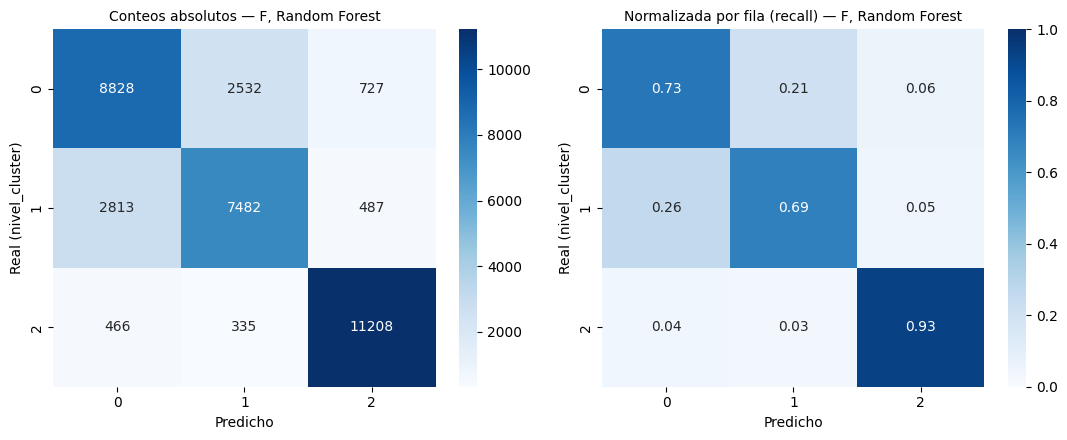

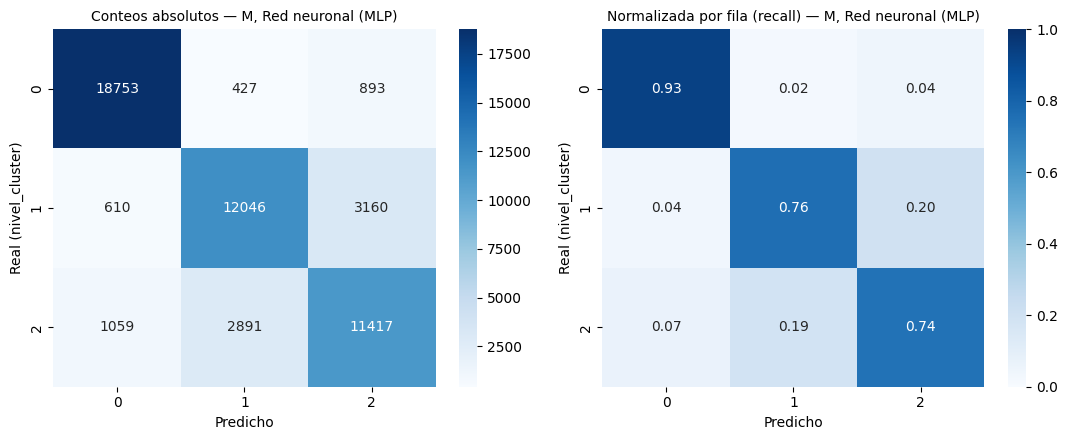

In [16]:
# ---------------------------------------------------------------------------
# MATRIZ DE CONFUSIÓN — mejor modelo por género, sobre el set de test
# ---------------------------------------------------------------------------
from sklearn.metrics import confusion_matrix

for genero in ["F", "M"]:
    sub_comp = comparacion_df[comparacion_df["genero"] == genero]
    mejor_modelo_nombre = sub_comp.iloc[0]["modelo"]
    mejor_estimador = modelos_entrenados[(genero, mejor_modelo_nombre)]

    X_test = resultados[genero]["X_test"]
    y_test = resultados[genero]["y_test"]
    pred_test = mejor_estimador.predict(X_test)

    cm = confusion_matrix(y_test, pred_test)
    cm_normalizada = confusion_matrix(y_test, pred_test, normalize="true")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
    axes[0].set_title(f"Conteos absolutos — {genero}, {mejor_modelo_nombre}", fontsize=10)
    axes[0].set_xlabel("Predicho")
    axes[0].set_ylabel("Real (nivel_cluster)")

    sns.heatmap(cm_normalizada, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
                xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()),
                vmin=0, vmax=1)
    axes[1].set_title(f"Normalizada por fila (recall) — {genero}, {mejor_modelo_nombre}", fontsize=10)
    axes[1].set_xlabel("Predicho")
    axes[1].set_ylabel("Real (nivel_cluster)")

    plt.tight_layout()
    plt.show()

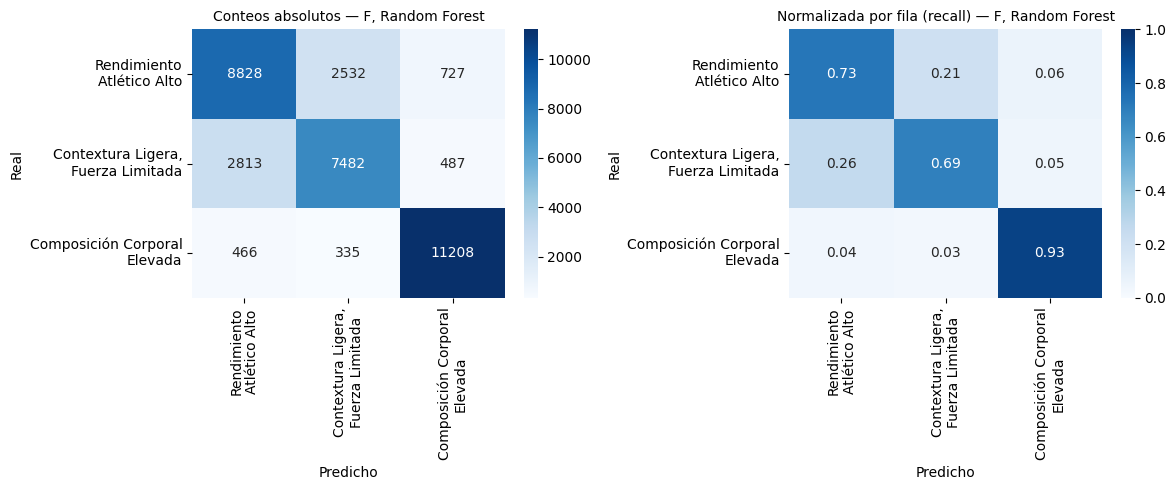

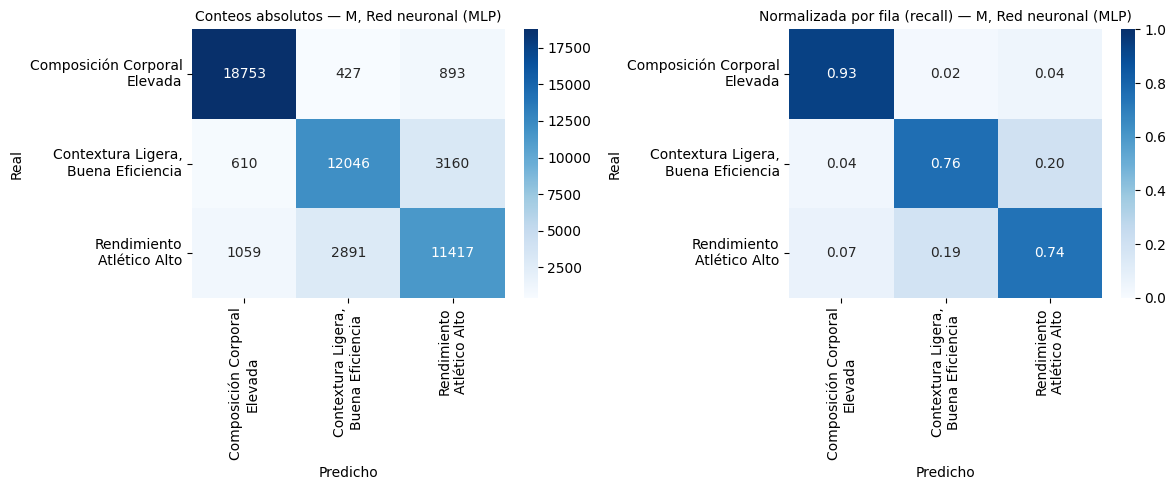

In [17]:
# ---------------------------------------------------------------------------
# MATRIZ DE CONFUSIÓN — mejor modelo por género, con nombres de cluster
# ---------------------------------------------------------------------------
from sklearn.metrics import confusion_matrix

NOMBRES_CLUSTER = {
    "F": {0: "Rendimiento\nAtlético Alto", 1: "Contextura Ligera,\nFuerza Limitada",
          2: "Composición Corporal\nElevada"},
    "M": {0: "Composición Corporal\nElevada", 1: "Contextura Ligera,\nBuena Eficiencia",
          2: "Rendimiento\nAtlético Alto"},
}

for genero in ["F", "M"]:
    sub_comp = comparacion_df[comparacion_df["genero"] == genero]
    mejor_modelo_nombre = sub_comp.iloc[0]["modelo"]
    mejor_estimador = modelos_entrenados[(genero, mejor_modelo_nombre)]

    X_test = resultados[genero]["X_test"]
    y_test = resultados[genero]["y_test"]
    pred_test = mejor_estimador.predict(X_test)

    clases_ordenadas = sorted(y_test.unique())
    etiquetas = [NOMBRES_CLUSTER[genero][c] for c in clases_ordenadas]

    cm = confusion_matrix(y_test, pred_test, labels=clases_ordenadas)
    cm_normalizada = confusion_matrix(y_test, pred_test, labels=clases_ordenadas, normalize="true")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=etiquetas, yticklabels=etiquetas)
    axes[0].set_title(f"Conteos absolutos — {genero}, {mejor_modelo_nombre}", fontsize=10)
    axes[0].set_xlabel("Predicho")
    axes[0].set_ylabel("Real")

    sns.heatmap(cm_normalizada, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
                xticklabels=etiquetas, yticklabels=etiquetas, vmin=0, vmax=1)
    axes[1].set_title(f"Normalizada por fila (recall) — {genero}, {mejor_modelo_nombre}", fontsize=10)
    axes[1].set_xlabel("Predicho")
    axes[1].set_ylabel("Real")

    plt.tight_layout()
    plt.show()

## Interpretación de la clasificación restringida (matrices de confusión)

**Hallazgo consistente en ambos géneros: el cluster de "Composición Corporal
Elevada" es, por mucho, el más fácil de predecir correctamente.** 
Y le cuesta más identificar a las otras dos clases. 

- **F (Random Forest):** recall de 0.93 para Composición Corporal Elevada,
  contra 0.73 (Rendimiento Atlético Alto) y 0.69 (Contextura Ligera, Fuerza
  Limitada).
- **M (Red neuronal MLP):** recall de 0.93 para Composición Corporal Elevada,
  contra 0.74 (Rendimiento Atlético Alto) y 0.76 (Contextura Ligera, Buena
  Eficiencia).

Composición Corporal Elevada se define principalmente
por peso, IMC y circunferencia de cintura — variables que están **directamente**
en el set restringido, medidas con precisión exacta, sin necesidad de
reconstrucción. En cambio, la diferencia entre los otros dos clusters depende
más de fuerza, potencia y capacidad cardiorrespiratoria — información que en
este modelo viene de variables **reconstruidas** (fórmula de Deurenberg para
grasa corporal, regresores auxiliares para agarre y VO2max).


- La confusión entre Composición Corporal Elevada y cualquiera de los otros
  dos clusters es mínima en ambos géneros (0.02–0.07) — el modelo casi nunca
  se equivoca en esa dirección.
- Casi toda la confusión ocurre **entre los dos clusters "delgados"**
  (Rendimiento Atlético Alto vs. Contextura Ligera): 0.21–0.26 en F, 0.19–0.20
  en M. Ambos comparten peso/IMC similares y se diferencian principalmente por
  desempeño funcional — justo la parte que el modelo restringido reconstruye
  en vez de medir directamente.

**Conclusión:** el clasificador restringido funciona muy bien
para detectar el segmento que más importa desde el punto de vista de salud
(Composición Corporal Elevada, con recall >0.9 en ambos géneros), y tiene un
desempeño razonable (0.69–0.76) diferenciando los dos niveles de rendimiento
más sutiles. Esta limitación es esperable y consistente con la arquitectura
del proyecto, se está reconstruyendo información de laboratorio a partir de
proxies.